In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score

import statsmodels.api as sm

df = pd.read_csv("dragon_data.csv")

print(df.head())

print(df.info())

# Summary statistics
print(df.describe())

      SPC   AGE     MASS   WSP   HID     SPD   FHO
0  Wyvern    16     1304   4.0  4.83    4800   611
1  Dragon  2726  3693174  52.0  4.82  114400  1960
2  Dragon   377   154201  19.4  4.61   42680  1123
3   Hydra   169    40146  13.0  2.65    7800   706
4  Dragon  1571  1549315  39.6  1.49   87120  1441
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPC     500 non-null    object 
 1   AGE     500 non-null    int64  
 2   MASS    500 non-null    int64  
 3   WSP     500 non-null    float64
 4   HID     500 non-null    float64
 5   SPD     500 non-null    int64  
 6   FHO     500 non-null    int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 27.5+ KB
None
              AGE          MASS         WSP         HID            SPD  \
count   500.00000  5.000000e+02  500.000000  500.000000     500.000000   
mean    461.47400  3.092487e+05   18.1994

In [ ]:
print(df.isnull().sum())

SPC     0
AGE     0
MASS    0
WSP     0
HID     0
SPD     0
FHO     0
dtype: int64


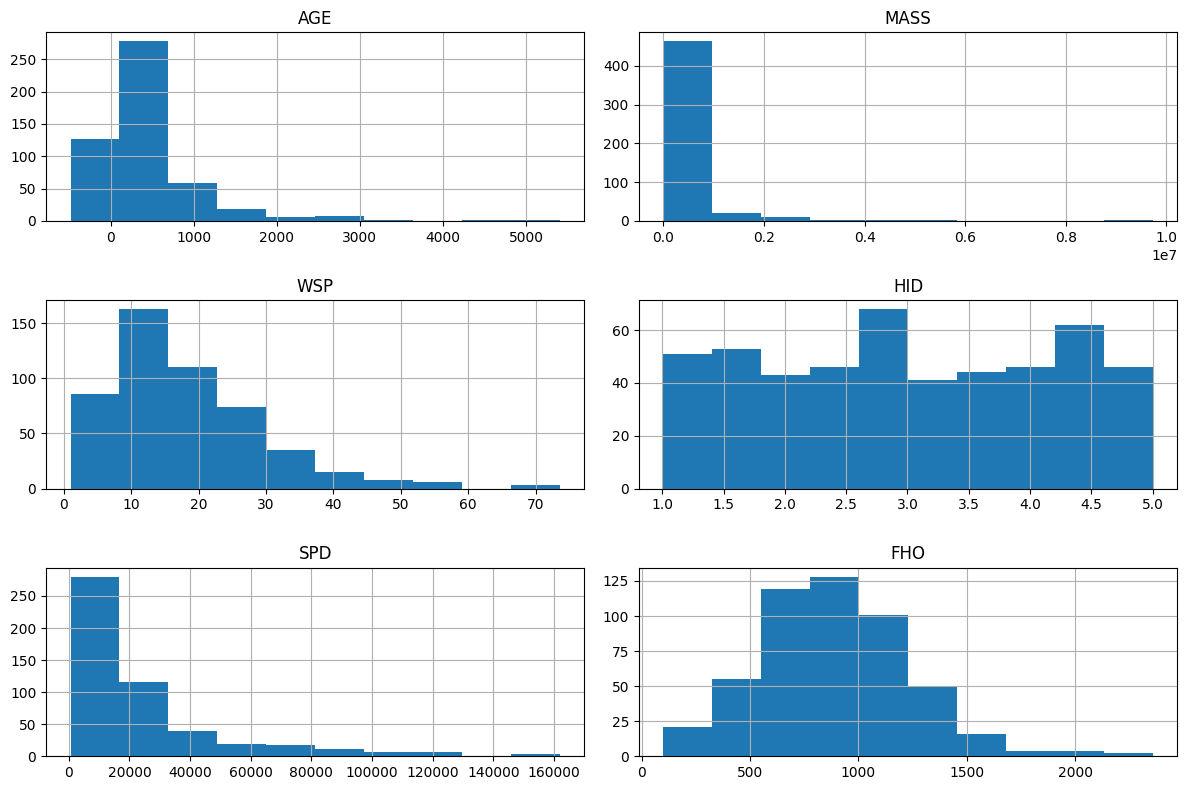

In [ ]:
numeric_cols = ['AGE', 'MASS', 'WSP', 'HID', 'SPD', 'FHO']

df[numeric_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

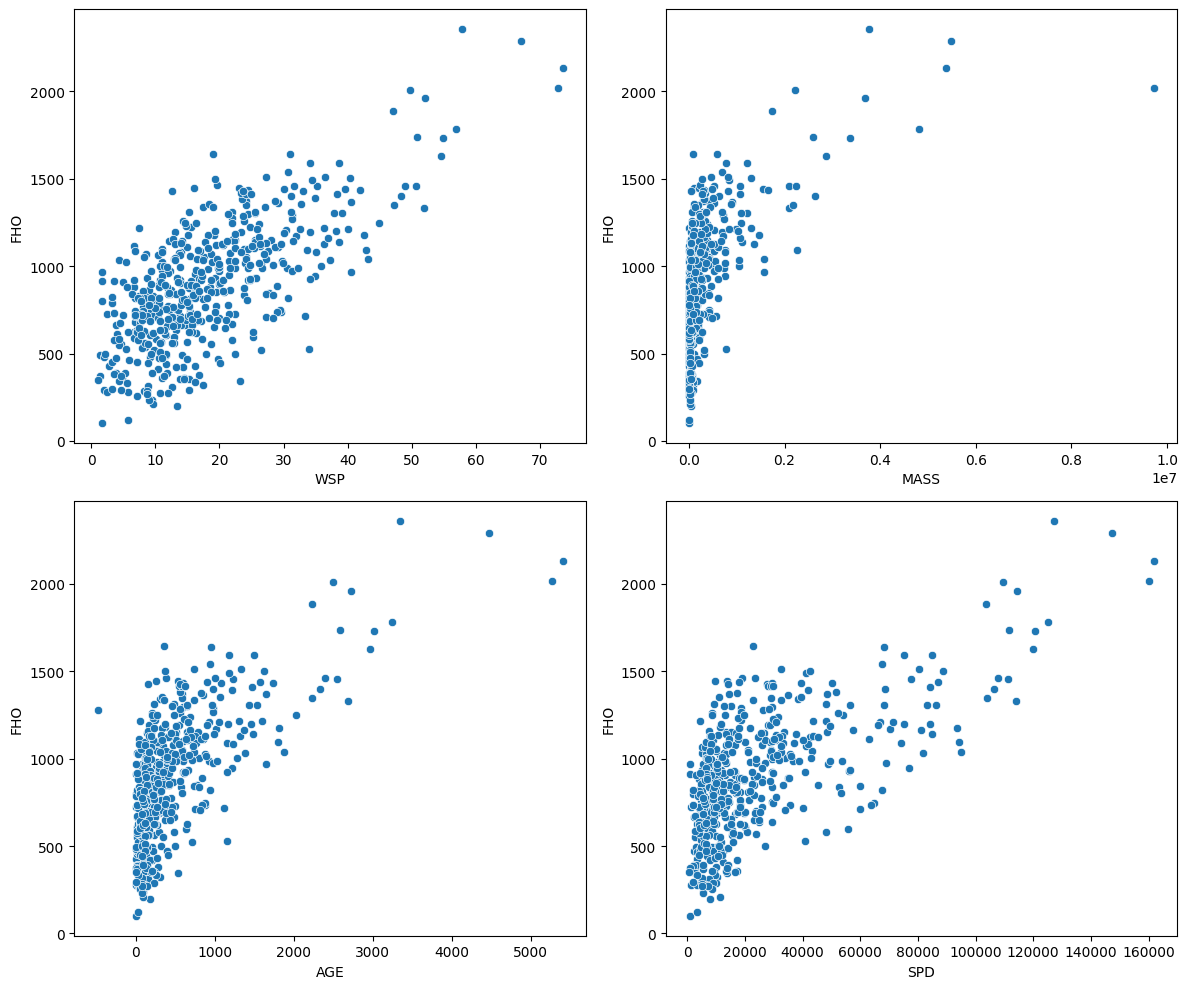

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

sns.scatterplot(data=df, x='WSP', y='FHO', ax=axes[0,0])
sns.scatterplot(data=df, x='MASS', y='FHO', ax=axes[0,1])
sns.scatterplot(data=df, x='AGE', y='FHO', ax=axes[1,0])
sns.scatterplot(data=df, x='SPD', y='FHO', ax=axes[1,1])

plt.tight_layout()
plt.show()

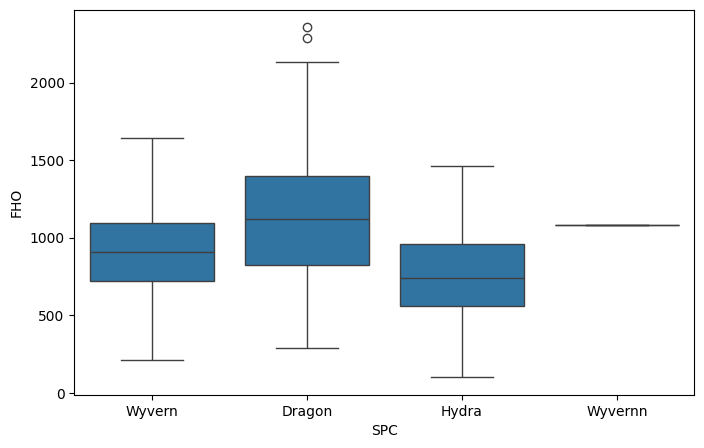

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='SPC', y='FHO')
plt.show()

In [ ]:
# Converting categorical variable

df_encoded = pd.get_dummies(df, columns=['SPC'], drop_first=True)

X = df_encoded.drop('FHO', axis=1)
y = df_encoded['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X = df[['WSP']]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_wsp = LinearRegression()
model_wsp.fit(X_train, y_train)

train_pred = model_wsp.predict(X_train)
test_pred = model_wsp.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print('Train R2:', train_r2)
print('Test R2:', test_r2)

Train R2: 0.494672105612152
Test R2: 0.5416536400319366


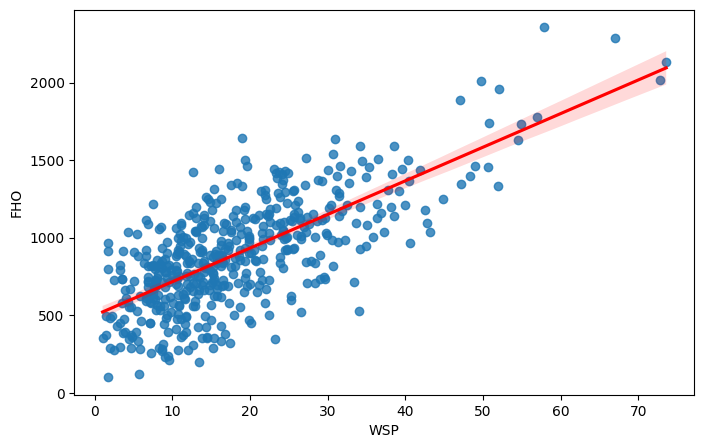

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='WSP', y='FHO', line_kws={'color':'red'})
plt.show()

hccvdchdcgh

In [ ]:
X = df[['MASS']]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_mass = LinearRegression()
model_mass.fit(X_train, y_train)

train_pred = model_mass.predict(X_train)
test_pred = model_mass.predict(X_test)

print('Train R2:', r2_score(y_train, train_pred))
print('Test R2:', r2_score(y_test, test_pred))

Train R2: 0.3316798226981259
Test R2: 0.36006158360421603


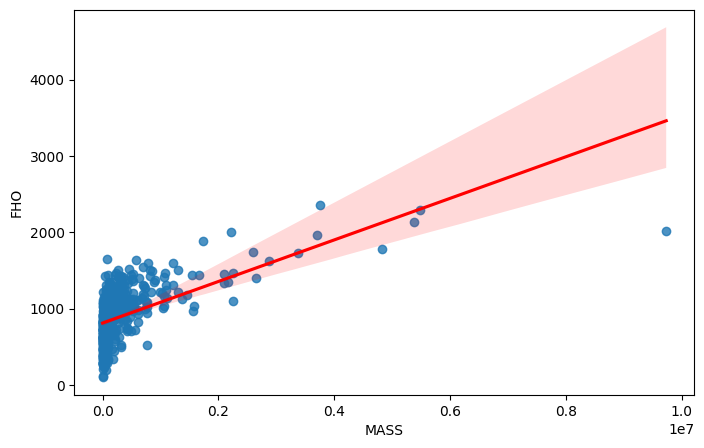

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='MASS', y='FHO', line_kws={'color':'red'})
plt.show()

In [ ]:
X = df[['AGE']]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_age = LinearRegression()
model_age.fit(X_train, y_train)

train_pred = model_age.predict(X_train)
test_pred = model_age.predict(X_test)

print('Train R2:', r2_score(y_train, train_pred))
print('Test R2:', r2_score(y_test, test_pred))

Train R2: 0.4335896587740389
Test R2: 0.4786814734073791


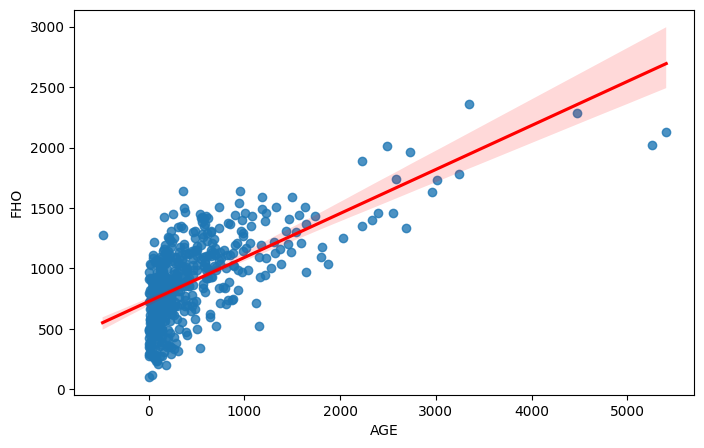

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='AGE', y='FHO', line_kws={'color':'red'})
plt.show()

In [ ]:
features = ['WSP', 'MASS']

X = df[features]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model1 = LinearRegression()
model1.fit(X_train, y_train)

train_pred = model1.predict(X_train)
test_pred = model1.predict(X_test)

print('Train R2:', r2_score(y_train, train_pred))
print('Test R2:', r2_score(y_test, test_pred))

Train R2: 0.49553638193211946
Test R2: 0.5423836106808952


In [ ]:
features = ['WSP', 'MASS', 'AGE']

X = df[features]
y = df['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train, y_train)

train_pred = model2.predict(X_train)
test_pred = model2.predict(X_test)

print('Train R2:', r2_score(y_train, train_pred))
print('Test R2:', r2_score(y_test, test_pred))

Train R2: 0.49705180327634235
Test R2: 0.5431216327395993


In [ ]:
X = df_encoded.drop('FHO', axis=1)
y = df_encoded['FHO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

full_model = LinearRegression()
full_model.fit(X_train, y_train)

train_pred = full_model.predict(X_train)
test_pred = full_model.predict(X_test)

print('Train R2:', r2_score(y_train, train_pred))
print('Test R2:', r2_score(y_test, test_pred))

Train R2: 0.503316493789389
Test R2: 0.5401764064756452


In [ ]:
results = pd.DataFrame({
    'Model': ['WSP', 'MASS', 'AGE', 'SPC', 'Full Model'],
    'Train_R2': [0,0,0,0,0],
    'Test_R2': [0,0,0,0,0]
})

print(results)

        Model  Train_R2  Test_R2
0         WSP         0        0
1        MASS         0        0
2         AGE         0        0
3         SPC         0        0
4  Full Model         0        0


In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': full_model.coef_
})

print(coefficients)

       Feature  Coefficient
0          AGE    -0.102824
1         MASS     0.000076
2          WSP    22.962594
3          HID     6.090633
4          SPD    -0.001134
5    SPC_Hydra  -106.309908
6   SPC_Wyvern   -54.443408
7  SPC_Wyvernn  -197.639455


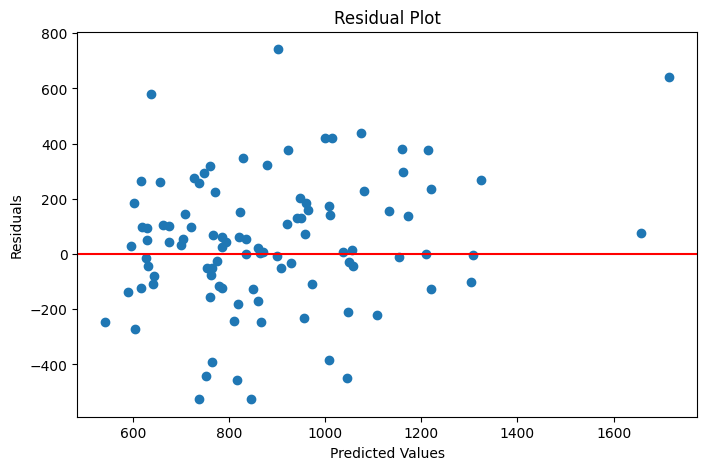

In [ ]:
residuals = y_test - test_pred

plt.figure(figsize=(8,5))
plt.scatter(test_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mae = mean_absolute_error(y_test, test_pred)

print('RMSE:', rmse)
print('MAE:', mae)

RMSE: 240.53166837131724
MAE: 181.42976256905564


In [ ]:
scores = cross_val_score(
    full_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)
print('Mean CV Score:', scores.mean())

[0.44816597 0.53069358 0.4196309  0.54313413 0.40735387]
Mean CV Score: 0.4697956904518533
